In [36]:
%matplotlib inline
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle,ConnectionPatch
from matplotlib.gridspec import GridSpec
import pandas as pd
typeface='Helvetica Neue'
mpl.rcParams['font.weight']=300
mpl.rcParams['axes.labelweight']=300
mpl.rcParams['font.family']=typeface
mpl.rcParams['font.size']=22
mpl.rcParams['pdf.fonttype']=42

import os,glob
import numpy as np
import baltic as bt
import cartopy
import cartopy.crs as ccrs
from cartopy import crs, feature as cf
import geoviews as gv
import geoviews.feature as gf
from geoviews import opts

/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_63008/3962572770.py:17: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax=plt.subplot(gs[0],zorder=1000,facecolor='none')


[]

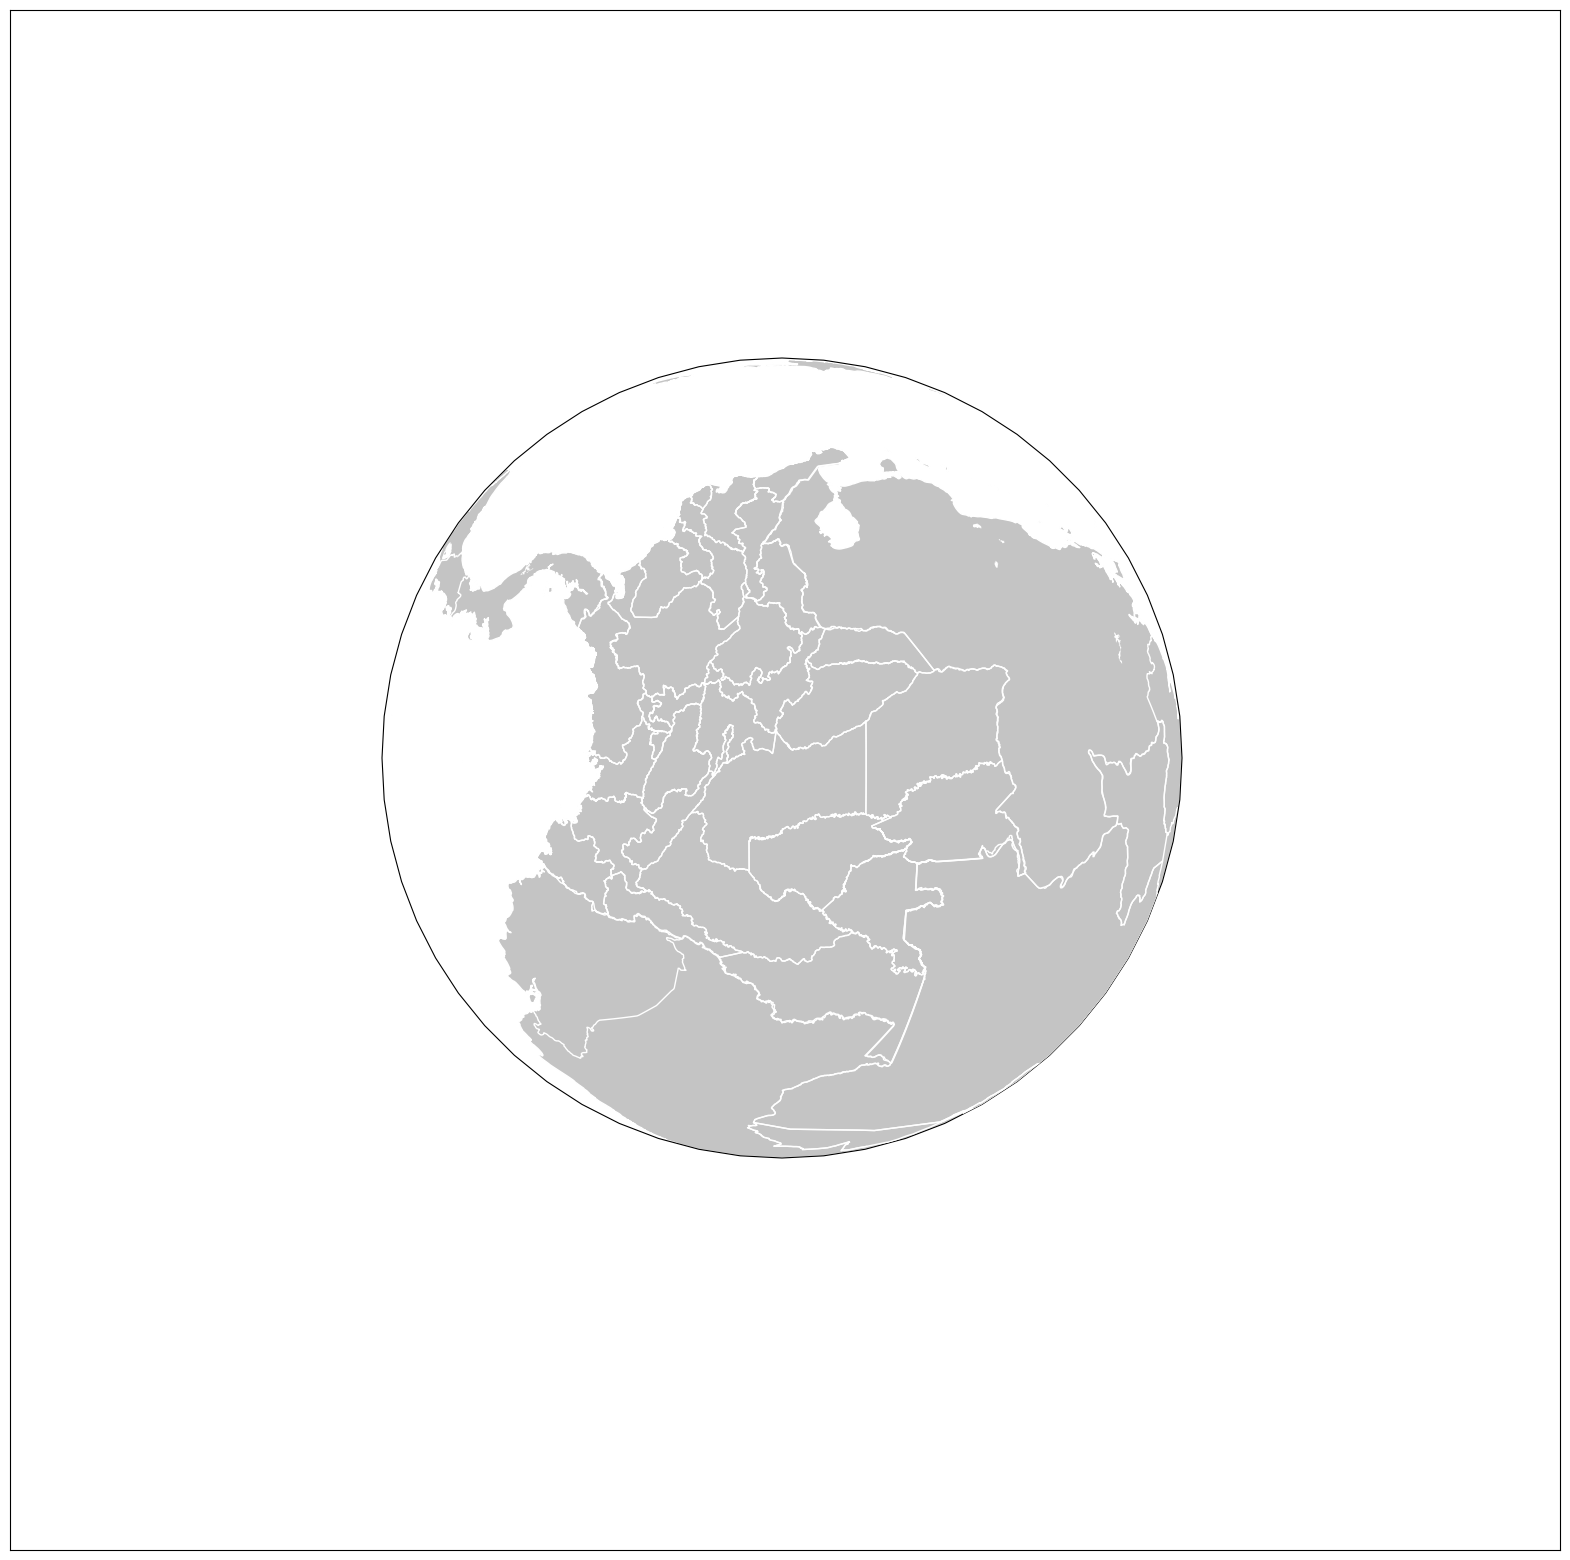

In [14]:
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature
import cartopy
import cartopy.crs as ccrs
from cartopy import crs, feature as cf
import geoviews as gv
import geoviews.feature as gf
from geoviews import opts
import geopandas as gpd

shpname = '/Users/ricardorivero/Documents/DENV/2024/geoBoundaries-COL-ADM1.geojson'
gdf = gpd.read_file(shpname)

fig,ax = plt.subplots(figsize=(20,20),facecolor='w')

gs = GridSpec(1,1,hspace=0.01,wspace=0.0)
ax=plt.subplot(gs[0],zorder=1000,facecolor='none')


ortho=ccrs.NearsidePerspective(central_longitude=-72.9301367,central_latitude=4.1156735,satellite_height=300000) ## projection

w=0.3
ax2=fig.add_axes([(1-w)/2, (1-w)/2, w, w],facecolor='none',projection=ortho,zorder=0) ## add sub-axes

[ax2.spines[loc].set_visible(False) for loc in ax.spines] ## no spines for the plot

p1 = ax.get_position()
p2 = ax2.get_position()

scale=2
w=0.4
# ax2.set_position([(1-w)/2+0.011, (1-w)/2+0.002, w, w]) ## adjust position of map subplot, it's not perfectly centered
ax2.set_position([(1-w)/2+0.011, (1-w)/2+0.006, w, w]) ## adjust position of map subplot, it's not perfectly centered

## map scale and colour
scale='10m'
# water='#CED6D9'
water='w'
# land='#848E86'
land='#c4c4c4'

## add water bodies, continents and country borders
ax2.add_feature(cartopy.feature.LAKES.with_scale(scale),facecolor=water)
ax2.add_feature(cartopy.feature.OCEAN.with_scale(scale),facecolor=water,edgecolor=water)
ax2.add_feature(cartopy.feature.LAND.with_scale(scale),facecolor=land,edgecolor='w')
ax2.add_feature(cartopy.feature.BORDERS.with_scale(scale),edgecolor='w',lw=1,zorder=1)
ax2.add_feature(cartopy.feature.STATES, linewidth=1, edgecolor='w', zorder=100);

# Add the GeoJSON feature to the main map
ax2.add_geometries(gdf.geometry, ccrs.PlateCarree(), edgecolor='w', facecolor='none', linewidth=1, zorder=10)

## remove ticks and tick labels from everything
ax.set_xticks([])
ax.set_xticklabels([])
ax.set_yticks([])
ax.set_yticklabels([])

ax2.set_xticks([])
ax2.set_xticklabels([])
ax2.set_yticks([])
ax2.set_yticklabels([])



Tree height: 20.528712
Tree length: 310.470851
strictly bifurcating tree

Numbers of objects in tree: 349 (174 nodes and 175 leaves)



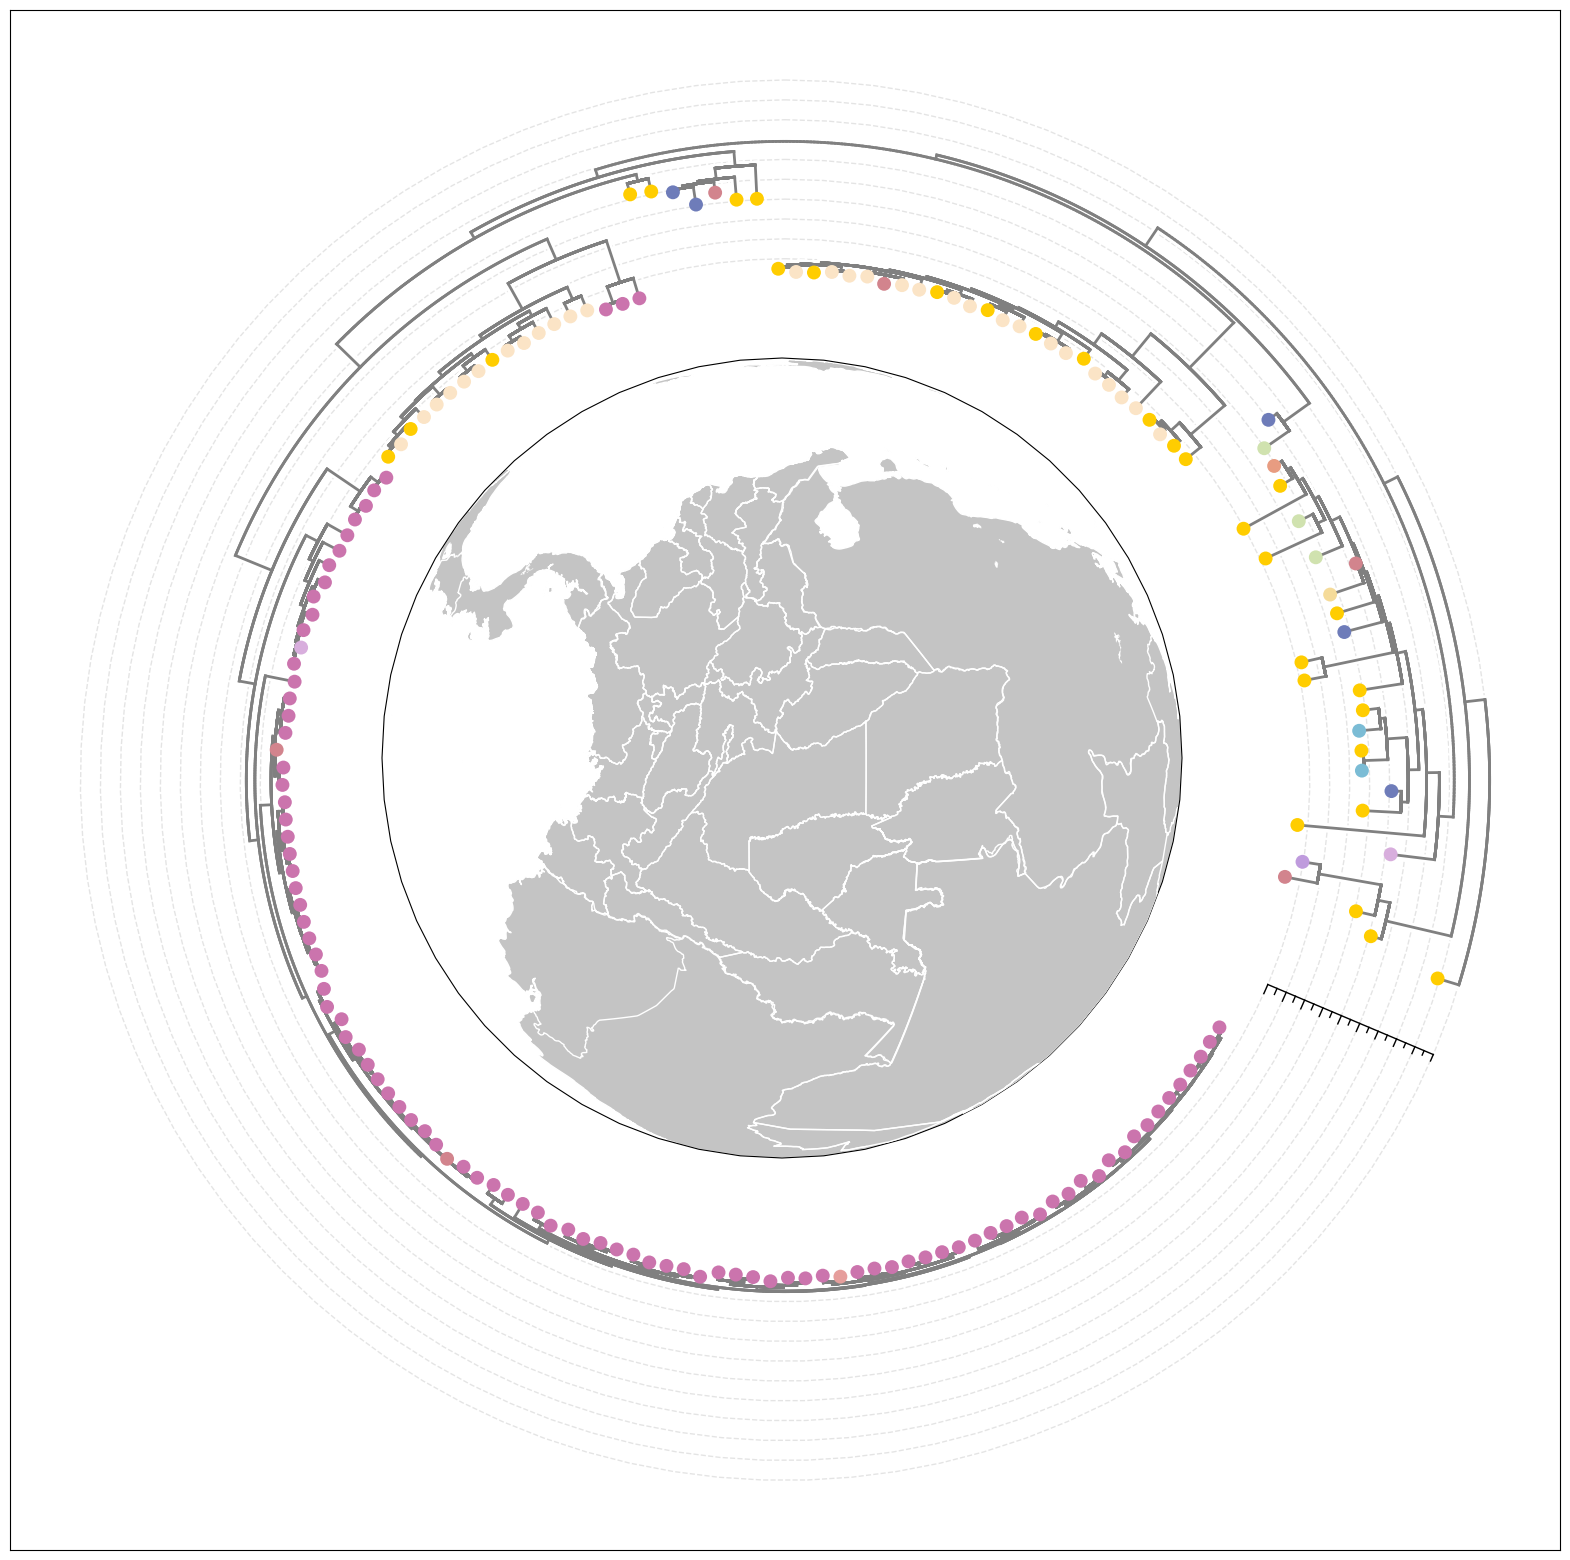

In [117]:
import matplotlib.pyplot as plt
import pandas as pd
import baltic as bt
import numpy as np
import cartopy.crs as ccrs
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec

# Departments and their colors
colors = {
    'Tolima': '#6e7cb9', 'Casanare': '#7bbcd5', 'Huila': '#d0e2af',
    'Norte de Santander': '#f5db99', 'Arauca': '#e89c81', 'Meta': '#d2848d',
    'Cauca': '#d8aedd', 'Cordoba': '#bf9bdd', 'Valle del Cauca': '#cb74ad',
    'Antioquia': '#e69e9c', 'NA': 'yellow', 'Amazonas':'#fbe4c6'
}

fig, ax = plt.subplots(figsize=(20, 20), facecolor='w')

# Read metadata
metadata = pd.read_csv('/Users/ricardorivero/Documents/DENV/2024/Metadata/D2_col_geocoded.csv')

# Load phylogenetic tree
ll = bt.loadNexus('/Users/ricardorivero/Documents/DENV/2024/D2/all_colombia/MSBD/BDSKY/exported_tree_d2.nexus', absoluteTime=False)
ll.setAbsoluteTime(2024.306)

ll.treeStats()

# Function to add metadata to tree nodes
def add_metadata(k):
    if k.is_leaf():
        accession_id = k.name.split('/')[0]  # Extract the accession_id before the first "/"
        if accession_id in metadata['accession_id'].values:
            k.traits['country'] = metadata.loc[metadata['accession_id'] == accession_id, 'country'].values[0]
            k.traits['state'] = metadata.loc[metadata['accession_id'] == accession_id, 'state'].values[0]
            k.traits['date'] = metadata.loc[metadata['accession_id'] == accession_id, 'collection_date.x'].values[0]
            k.traits['lat'] = metadata.loc[metadata['accession_id'] == accession_id, 'latitude'].values[0]
            k.traits['lon'] = metadata.loc[metadata['accession_id'] == accession_id, 'longitude'].values[0]

# Apply metadata to all objects in the tree
for k in ll.Objects:
    add_metadata(k)

# Polar transform function with map integration and tip colors
def polar_transform(ax, tree, circStart=0.0, circFrac=1.0, inwardSpace=0.0, precision=20):
    x_attr=lambda k:k.x
    y_attr=lambda k:k.y
    colour=lambda k: colors[k.traits['state']] if 'state' in k.traits and k.traits['state'] in colors else '#FFCD00'
    width=2

    if inwardSpace < 0: inwardSpace -= tree.treeHeight

    branches = []
    cs = []
    linewidths = []

    circ_s = circStart * np.pi * 2
    circ = circFrac * np.pi * 2

    allXs = list(map(x_attr, tree.Objects))
    allXs.append(max(allXs) * 1.1)
    normaliseHeight = lambda value: (value - min(allXs)) / (max(allXs) - min(allXs))
    linspace = lambda start, stop, n: list(start + ((stop - start) / (n - 1)) * i for i in range(n)) if n > 1 else stop

    y0 = circ_s - 0.1
    x0 = normaliseHeight(0 + inwardSpace)
    x1 = normaliseHeight(18 + inwardSpace)

    ax.plot([np.sin(y0)*x0,np.sin(y0)*x1],[np.cos(y0)*x0,np.cos(y0)*x1],color='k',lw=1)

    for i in range(0,19):
        w=0.01+i*0.0005
        y_line=np.linspace(y0,y0+w,10) if i%2==0 else np.linspace(y0,y0+w/1.5,10)
        x=normaliseHeight(i+inwardSpace)
        ax.plot(np.sin(y_line)*x,np.cos(y_line)*x,color='k',lw=1)
        if (i)%2==0:
            ax.plot(np.sin(np.linspace(-np.pi,np.pi,100))*x,np.cos(np.linspace(-np.pi,np.pi,100))*x,color='lightgrey',ls='--',alpha=0.6,lw=1,zorder=0)

    for k in tree.Objects:
        x = normaliseHeight(x_attr(k) + inwardSpace)
        xp = normaliseHeight(x_attr(k.parent) + inwardSpace) if k.parent.parent else x
        y = y_attr(k)

        branch_color = colour(k)
        cs.append('grey')
        linewidths.append(width(k) if callable(width) else width)

        y = circ_s + circ * y / tree.ySpan
        X = np.sin(y)
        Y = np.cos(y)
        branches.append(((X * xp, Y * xp), (X * x, Y * x)))

        if k.is_node():
            yl,yr=y_attr(k.children[0]),y_attr(k.children[-1])
            yl=circ_s+circ*yl/tree.ySpan
            yr=circ_s+circ*yr/tree.ySpan
            ybar=linspace(yl,yr,precision)

            xs=[yx*x for yx in np.sin(ybar)]
            ys=[yy*x for yy in np.cos(ybar)]

            branches+=tuple(zip(zip(xs,ys),zip(xs[1:],ys[1:])))
            linewidths+=[linewidths[-1] for q in zip(ys,ys[1:])]
            cs+=[cs[-1] for q in zip(ys,ys[1:])]
        else:
            s = 50
            ax.scatter(X * x, Y * x, s=100, facecolor=branch_color, edgecolor='none', zorder=10000)  # Plot the tip

    line_segments = LineCollection(branches, lw=linewidths, ls='-', color=cs, capstyle='projecting', zorder=2)
    ax.add_collection(line_segments)

    line_segments = LineCollection(branches, lw=[lw * 3 for lw in linewidths], ls='-', color=['w' for c in cs], capstyle='projecting', zorder=1)
    ax.add_collection(line_segments)

ll.drawTree()


ortho=ccrs.NearsidePerspective(central_longitude=-72.9301367,central_latitude=4.1156735,satellite_height=300000) ## projection

w=0.3
ax2=fig.add_axes([(1-w)/2, (1-w)/2, w, w],facecolor='none',projection=ortho,zorder=0) ## add sub-axes

[ax2.spines[loc].set_visible(False) for loc in ax.spines] ## no spines for the plot

p1 = ax.get_position()
p2 = ax2.get_position()

scale=2
w=0.4
# ax2.set_position([(1-w)/2+0.011, (1-w)/2+0.002, w, w]) ## adjust position of map subplot, it's not perfectly centered
ax2.set_position([(1-w)/2+0.011, (1-w)/2+0.006, w, w]) ## adjust position of map subplot, it's not perfectly centered

## map scale and colour
scale='10m'
# water='#CED6D9'
water='w'
# land='#848E86'
land='#c4c4c4'

## add water bodies, continents and country borders
ax2.add_feature(cartopy.feature.LAKES.with_scale(scale),facecolor=water)
ax2.add_feature(cartopy.feature.OCEAN.with_scale(scale),facecolor=water,edgecolor=water)
ax2.add_feature(cartopy.feature.LAND.with_scale(scale),facecolor=land,edgecolor='w')
ax2.add_feature(cartopy.feature.BORDERS.with_scale(scale),edgecolor='w',lw=1,zorder=1)
ax2.add_feature(cartopy.feature.STATES, linewidth=1, edgecolor='w', zorder=100);

# Add the GeoJSON feature to the main map
ax2.add_geometries(gdf.geometry, ccrs.PlateCarree(), edgecolor='w', facecolor='none', linewidth=1, zorder=10)



# Now apply polar_transform with your tree
polar_transform(ax, ll, circStart=0.83, circFrac=0.97, inwardSpace=-50, precision=200)

## remove ticks and tick labels from everything
ax.set_xticks([])
ax.set_xticklabels([])
ax.set_yticks([])
ax.set_yticklabels([])

ax2.set_xticks([])
ax2.set_xticklabels([])
ax2.set_yticks([])
ax2.set_yticklabels([])
plt.show()


Tree height: 20.528712
Tree length: 310.470851
strictly bifurcating tree

Numbers of objects in tree: 349 (174 nodes and 175 leaves)



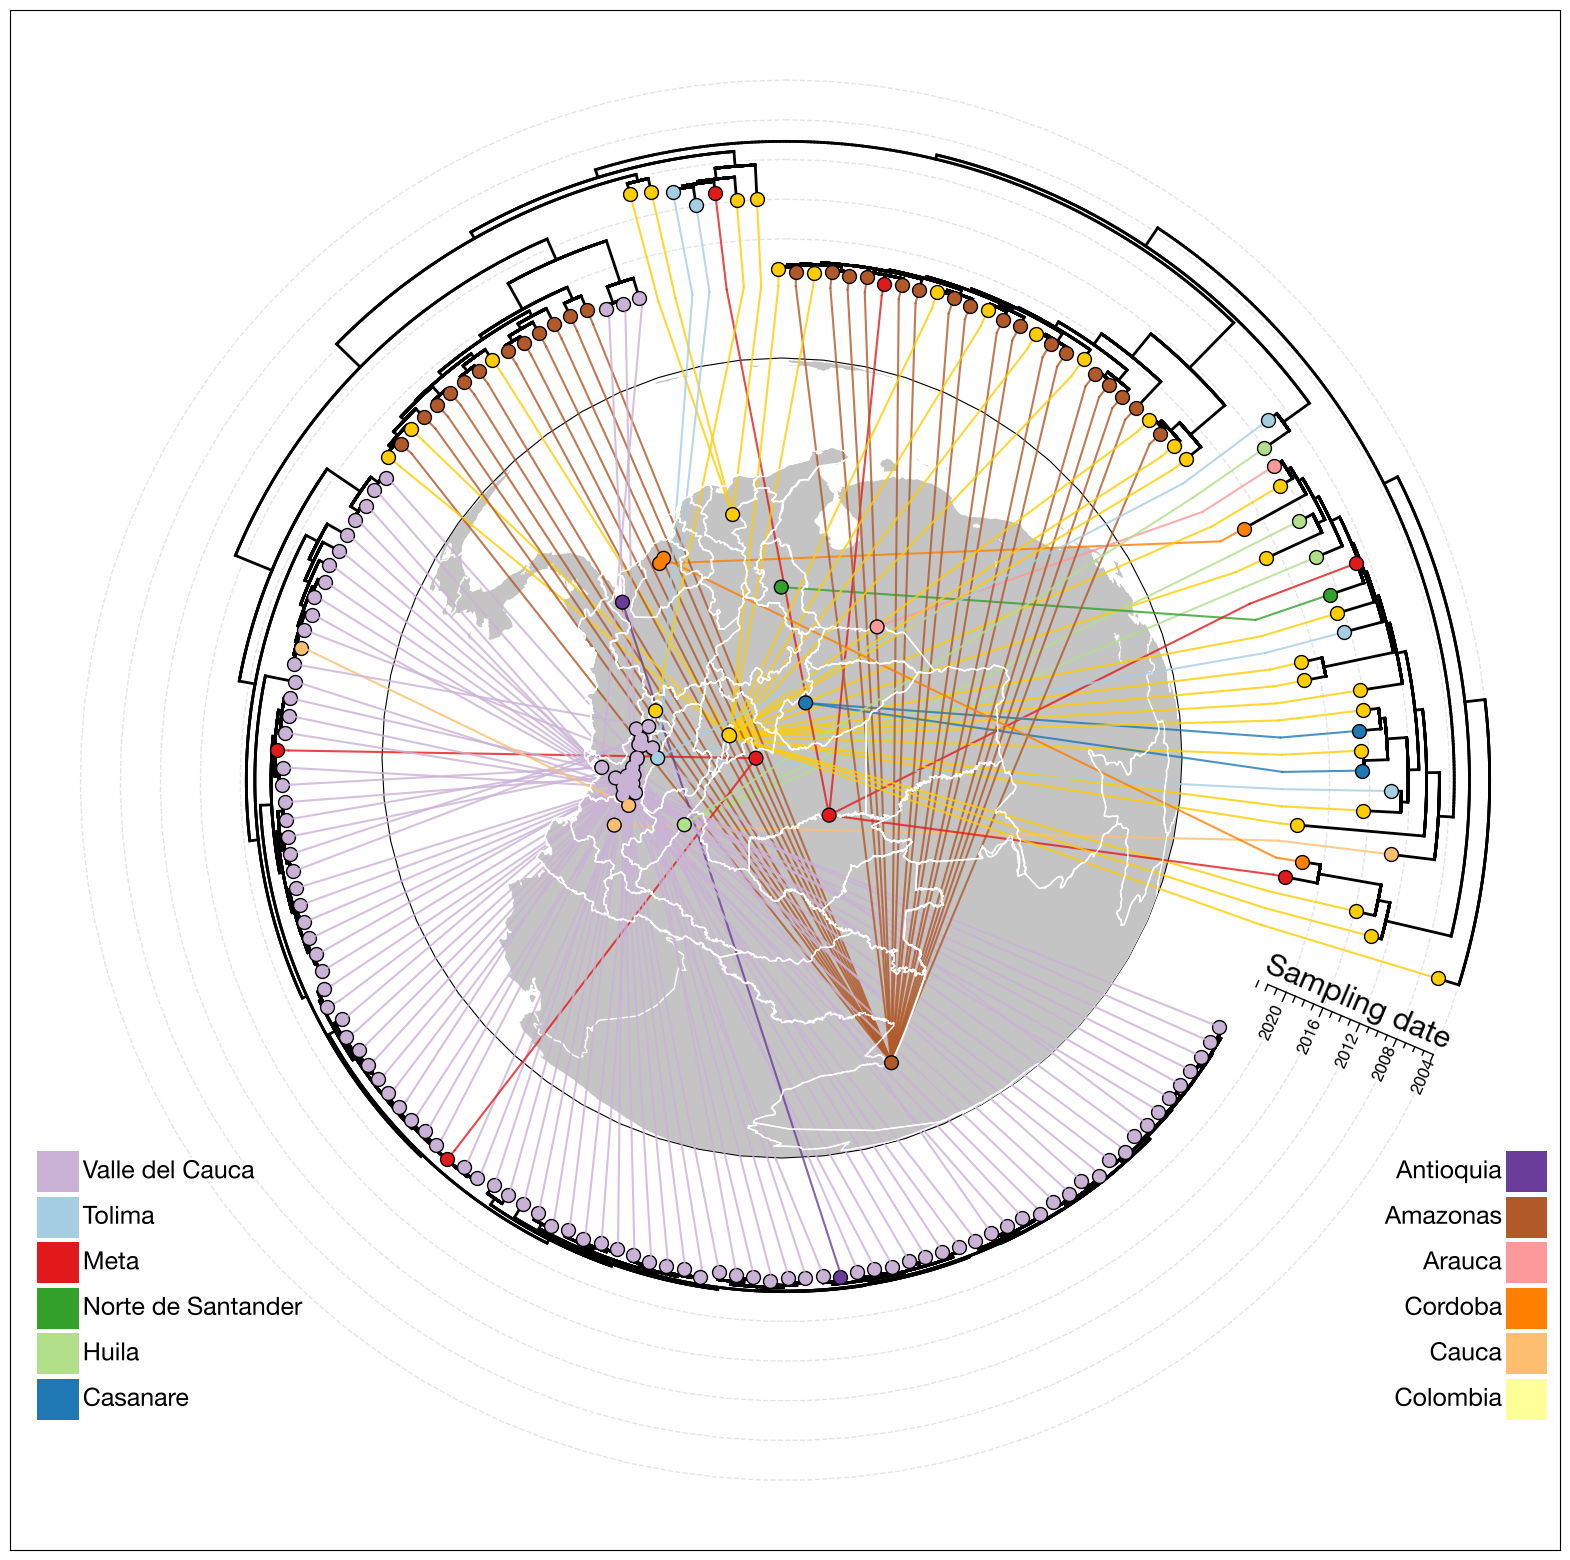

In [152]:
import matplotlib.pyplot as plt
import pandas as pd
import baltic as bt
import numpy as np
import cartopy.crs as ccrs
from matplotlib.collections import LineCollection
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Departments and their colors
colors = {
    'Tolima': '#a6cee3', 'Casanare': '#1f78b4', 'Huila': '#b2df8a',
    'Norte de Santander': '#33a02c', 'Arauca': '#fb9a99', 'Meta': '#e31a1c',
    'Cauca': '#fdbf6f', 'Cordoba': '#ff7f00', 'Valle del Cauca': '#cab2d6',
    'Antioquia': '#6a3d9a', 'NA': '#ffff99', 'Amazonas':'#b15928'
}

fig, ax = plt.subplots(figsize=(20, 20), facecolor='w')

# Read metadata
metadata = pd.read_csv('/Users/ricardorivero/Documents/DENV/2024/Metadata/D2_col_geocoded.csv')

# Load phylogenetic tree
ll = bt.loadNexus('/Users/ricardorivero/Documents/DENV/2024/D2/all_colombia/MSBD/BDSKY/exported_tree_d2.nexus', absoluteTime=False)
ll.setAbsoluteTime(2024.306)

ll.treeStats()

# Function to add metadata to tree nodes
def add_metadata(k):
    if k.is_leaf():
        accession_id = k.name.split('/')[0]  # Extract the accession_id before the first "/"
        if accession_id in metadata['accession_id'].values:
            k.traits['country'] = metadata.loc[metadata['accession_id'] == accession_id, 'country'].values[0]
            k.traits['state'] = metadata.loc[metadata['accession_id'] == accession_id, 'state'].values[0]
            k.traits['date'] = metadata.loc[metadata['accession_id'] == accession_id, 'collection_date.x'].values[0]
            k.traits['lat'] = metadata.loc[metadata['accession_id'] == accession_id, 'latitude'].values[0]
            k.traits['lon'] = metadata.loc[metadata['accession_id'] == accession_id, 'longitude'].values[0]

# Apply metadata to all objects in the tree
for k in ll.Objects:
    add_metadata(k)

# Polar transform function with map integration and tip colors and lines
def polar_transform(ax, tree, circStart=0.0, circFrac=1.0, inwardSpace=0.0, precision=20):
    x_attr=lambda k:k.x
    y_attr=lambda k:k.y
    colour=lambda k: colors[k.traits['state']] if 'state' in k.traits and k.traits['state'] in colors else '#FFCD00'
    width=2

    if inwardSpace < 0: inwardSpace -= tree.treeHeight

    branches = []
    cs = []
    linewidths = []

    circ_s = circStart * np.pi * 2
    circ = circFrac * np.pi * 2

    allXs = list(map(x_attr, tree.Objects))
    allXs.append(max(allXs) * 1.1)
    normaliseHeight = lambda value: (value - min(allXs)) / (max(allXs) - min(allXs))
    linspace = lambda start, stop, n: list(start + ((stop - start) / (n - 1)) * i for i in range(n)) if n > 1 else stop

    done = []

    y0 = circ_s - 0.1
    x0 = normaliseHeight(0 + inwardSpace)
    x1 = normaliseHeight(18 + inwardSpace)

    ax.plot([np.sin(y0)*x0,np.sin(y0)*x1],[np.cos(y0)*x0,np.cos(y0)*x1],color='k',lw=1)

    for i in range(0,20):
        w=0.01+i*0.0005
        y_line=np.linspace(y0,y0+w,10) if i%4==0 else np.linspace(y0,y0+w/1.5,10)
        x=normaliseHeight(i+inwardSpace)
        ax.plot(np.sin(y_line)*x,np.cos(y_line)*x,color='k',lw=1)
        if (i)%4==0:
            ax.plot(np.sin(np.linspace(-np.pi,np.pi,100))*x,np.cos(np.linspace(-np.pi,np.pi,100))*x,color='lightgrey',ls='--',alpha=0.6,lw=1,zorder=0)
            ax.text(np.sin(y_line[-1]+w*2.4)*x,np.cos(y_line[-1]+w*2.4)*x,'%d'%(2004+i),ha='center',size=12,va='center',rotation=-np.rad2deg(y_line[-1])) ## add tick label
    
    #### scale bar label
    ax.text(np.sin(y0-0.03)*np.mean([x0,x1]),np.cos(y0-0.03)*np.mean([x0,x1]),'Sampling date',ha='center',va='center',rotation=-np.rad2deg(y0)-90)
    

    for k in tree.Objects:
        x = normaliseHeight(x_attr(k) + inwardSpace)
        xp = normaliseHeight(x_attr(k.parent) + inwardSpace) if k.parent.parent else x
        y = y_attr(k)

        branch_color = colour(k)
        cs.append('k')
        linewidths.append(width(k) if callable(width) else width)

        y = circ_s + circ * y / tree.ySpan
        X = np.sin(y)
        Y = np.cos(y)
        branches.append(((X * xp, Y * xp), (X * x, Y * x)))

        if k.is_node():
            yl,yr=y_attr(k.children[0]),y_attr(k.children[-1])
            yl=circ_s+circ*yl/tree.ySpan
            yr=circ_s+circ*yr/tree.ySpan
            ybar=linspace(yl,yr,precision)

            xs=[yx*x for yx in np.sin(ybar)]
            ys=[yy*x for yy in np.cos(ybar)]

            branches+=tuple(zip(zip(xs,ys),zip(xs[1:],ys[1:])))
            linewidths+=[linewidths[-1] for q in zip(ys,ys[1:])]
            cs+=[cs[-1] for q in zip(ys,ys[1:])]
        else:
            s = 50
            ax.scatter(X * x, Y * x, s=100, facecolor=branch_color, edgecolor='k', zorder=10000)  # Plot the tip

            # Draw a line connecting the tip to the map coordinates
            if 'lat' in k.traits and 'lon' in k.traits:
                lat, lon = k.traits['lat'], k.traits['lon']
                # Transform the lat/lon point into the map projection
                latT,lonT=ortho.transform_point(lon, lat, ccrs.PlateCarree())
                # Draw the line from the tree tip (X, Y) to the map (map_x, map_y)
                al=0.8 ## connection lines will be slightly transparent
                lw=1.5 ## connection lines will be slightly thicker than regular
                ls='-' ## connection lines entire
                treeEnd=normaliseHeight(ll.treeHeight*1.01+inwardSpace) ## coordinate that sticks out a bit past the tree's highest point
                    
                ax.plot([X*treeEnd,X*x],[Y*treeEnd,Y*x],color=branch_color,ls=ls,lw=lw,alpha=al) ## draw line departing each tip and going off to some high point
                    
                con = ConnectionPatch(xyA=(X*treeEnd,Y*treeEnd), ## connect end of the line that departed a tip
                                          coordsA=ax.transData, ## coordinate provided is in dat aspace
                                          axesA=ax, ## tree part of the plot
                                          xyB=(latT,lonT), ## connect to map
                                          coordsB=ax2.transData, ## in map coordinates
                                          axesB=ax2, ## map part of the plot
                                          color=branch_color, ls=ls,lw=lw,zorder=3,alpha=al) ## colour, line style, linewidth, order, transparency
                ax2.add_patch(con) ## add line to plot
                    
                s=2 ## square marker size
                if (lon,lat) not in done: ## haven't done map coordinate before
                    ax2.scatter(lon,lat,s=40*s,facecolor=branch_color,edgecolor='none', ## plot circle on map
                                   zorder=10000,transform=ccrs.PlateCarree(),clip_on=False) 
                    ax2.scatter(lon,lat,s=60*s,facecolor='k',edgecolor='none', ## plot outline circles on map
                                   zorder=9999,transform=ccrs.PlateCarree(),clip_on=False)
                    done.append((lon,lat)) ## remember coordinate was done
    

    line_segments = LineCollection(branches, lw=linewidths, ls='-', color=cs, capstyle='projecting', zorder=2)
    ax.add_collection(line_segments)

    line_segments = LineCollection(branches, lw=[lw * 3 for lw in linewidths], ls='-', color=['w' for c in cs], capstyle='projecting', zorder=1)
    ax.add_collection(line_segments)

ll.drawTree()


ortho=ccrs.NearsidePerspective(central_longitude=-72.9301367,central_latitude=4.1156735,satellite_height=300000) ## projection

w=0.3
ax2=fig.add_axes([(1-w)/2, (1-w)/2, w, w],facecolor='none',projection=ortho,zorder=0) ## add sub-axes

[ax2.spines[loc].set_visible(False) for loc in ax.spines] ## no spines for the plot

p1 = ax.get_position()
p2 = ax2.get_position()

scale=2
w=0.4
# ax2.set_position([(1-w)/2+0.011, (1-w)/2+0.002, w, w]) ## adjust position of map subplot, it's not perfectly centered
ax2.set_position([(1-w)/2+0.011, (1-w)/2+0.006, w, w]) ## adjust position of map subplot, it's not perfectly centered

## map scale and colour
scale='10m'
# water='#CED6D9'
water='w'
# land='#848E86'
land='#c4c4c4'

## add water bodies, continents and country borders
ax2.add_feature(cartopy.feature.LAKES.with_scale(scale),facecolor=water)
ax2.add_feature(cartopy.feature.OCEAN.with_scale(scale),facecolor=water,edgecolor=water)
ax2.add_feature(cartopy.feature.LAND.with_scale(scale),facecolor=land,edgecolor='w')
ax2.add_feature(cartopy.feature.BORDERS.with_scale(scale),edgecolor='w',lw=1,zorder=1)
ax2.add_feature(cartopy.feature.STATES, linewidth=1, edgecolor='w', zorder=100);

# Add the GeoJSON feature to the main map
ax2.add_geometries(gdf.geometry, ccrs.PlateCarree(), edgecolor='w', facecolor='none', linewidth=1, zorder=10)



# Now apply polar_transform with your tree
polar_transform(ax, ll, circStart=0.83, circFrac=0.97, inwardSpace=-50, precision=200)

#add legend
## legend patch sizes
h=100000
w=100000

for c,state in enumerate(['Antioquia','Amazonas', 'Arauca','Cordoba', 'Cauca', 'NA'][::-1]): ## iterate over specific countries
    x=1750000 ## where legend patch starts horizontally
    y=-1600000+c*h*1.1 ## where legend patch starts vertically
    fc=colors[state] ## get colour
    
    effects=[path_effects.Stroke(linewidth=4, foreground='white'),
             path_effects.Stroke(linewidth=0, foreground='k')] ## black text, white outline
    
    if state=='NA': state='Colombia'
    ax2.add_patch(Rectangle((x,y),w,h,facecolor=fc,edgecolor='none',clip_on=False)) ## add coloured legend patch
    ax2.text(x-w*0.1,y+h/2,state,color='k',size=18,va='center',ha='right',path_effects=effects,zorder=1000000) ## label legend patch

    
for c,state in enumerate(['Casanare', 'Huila', 'Norte de Santander','Meta','Tolima','Valle del Cauca']): ## iterate over specific countries
    x=-1800000 ## where legend patch starts horizontally
    y=-1600000+c*h*1.1 ## where legend patch starts vertically
    fc=colors[state] ## get colour
    
    effects=[path_effects.Stroke(linewidth=4, foreground='white'),
             path_effects.Stroke(linewidth=0, foreground='k')] ## black text, white outline
    
    ax2.add_patch(Rectangle((x,y),w,h,facecolor=fc,edgecolor='none',clip_on=False)) ## add coloured legend patch
    ax2.text(x+w*1.1,y+h/2,state,color='k',size=18,va='center',ha='left',path_effects=effects,zorder=1000000) ## label legend patch


## remove ticks and tick labels from everything
ax.set_xticks([])
ax.set_xticklabels([])
ax.set_yticks([])
ax.set_yticklabels([])

ax2.set_xticks([])
ax2.set_xticklabels([])
ax2.set_yticks([])
ax2.set_yticklabels([])

#Save the figure

resolution=1200
plt.savefig('mapped_phylo.jpeg', dpi=resolution, bbox_inches='tight', format='jpeg')
plt.savefig('mapped_phylo.svg', dpi=resolution, bbox_inches='tight', format='svg')

plt.show()